In [11]:
from pathlib import Path
import runpy

BOOTSTRAP_CANDIDATES = (
    "notebooks/_bootstrap.py",
    "abstractgraph/notebooks/_bootstrap.py",
    "abstractgraph-ml/notebooks/_bootstrap.py",
    "abstractgraph-generative/notebooks/_bootstrap.py",
    "abstractgraph-graphicalizer/notebooks/_bootstrap.py",
)

_bootstrap_path = next(
    (
        candidate / relative
        for candidate in (Path.cwd(), *Path.cwd().parents)
        for relative in BOOTSTRAP_CANDIDATES
        if (candidate / relative).exists()
    ),
    None,
)
if _bootstrap_path is None:
    raise FileNotFoundError("Could not locate ecosystem notebooks/_bootstrap.py")

_bootstrap = runpy.run_path(str(_bootstrap_path))
repo_root = _bootstrap["repo_root"]
workspace_root = _bootstrap["workspace_root"]


In [12]:
%config InlineBackend.figure_format = 'retina'

import colorsys
import hashlib
import pickle
import random
from functools import lru_cache
from pathlib import Path

import matplotlib.pyplot as plt
import networkx as nx
import numpy as np
from IPython.display import display as display_figure
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor
from abstractgraph.operators import *
from abstractgraph.vectorize import AbstractGraphTransformer
from abstractgraph_ml.estimators import GraphEstimator
from abstractgraph_ml.feasibility import (
    FeasibilityEstimator,
    FeasibilityEstimatorFeatureCannotExist,
)
from abstractgraph_generative.edge_generator import EdgeGenerator, edge_neighbors


In [13]:
# Copied/adapted from ControlFlowGraphsForMalware/src/cic_sgg/visualization.py.
MAX_LAYOUT_NODES = 450
ROLE_MARKERS = {"entry": "s", "exit": "D", "internal": "o"}


def cfg_layout(graph: nx.DiGraph, random_seed: int = 1337):
    try:
        return nx.nx_pydot.graphviz_layout(graph, prog="dot")
    except Exception:
        return nx.spring_layout(graph, seed=random_seed)


def mnemonic_label(attrs):
    mnemonic = attrs.get("mnemonic") or attrs.get("label")
    if mnemonic:
        return str(mnemonic)
    node_label = attrs.get("node_label")
    if node_label and ":" in str(node_label):
        return str(node_label).split(":", 1)[1]
    return "unknown"


@lru_cache(maxsize=None)
def mnemonic_color(mnemonic: str | None) -> str:
    if not mnemonic or mnemonic == "unknown":
        return "#9d9d9d"
    digest = hashlib.md5(mnemonic.encode("utf-8")).hexdigest()
    hue = int(digest[:8], 16) / 0xFFFFFFFF
    red, green, blue = colorsys.hsv_to_rgb(hue, 0.62, 0.82)
    return f"#{round(red * 255):02x}{round(green * 255):02x}{round(blue * 255):02x}"


def node_role(attrs) -> str:
    role = attrs.get("node_role")
    if role in ROLE_MARKERS:
        return str(role)
    if attrs.get("is_entry"):
        return "entry"
    if attrs.get("is_exit"):
        return "exit"
    return "internal"


def draw_cfg_graph(
    graph: nx.DiGraph,
    ax: plt.Axes,
    random_seed: int = 1337,
    max_layout_nodes: int = MAX_LAYOUT_NODES,
) -> nx.DiGraph:
    """Draw a directed CFG-like NetworkX graph with nodes colored by mnemonic."""
    if graph.number_of_nodes() > max_layout_nodes:
        graph = graph.subgraph(list(graph.nodes())[:max_layout_nodes]).copy()
    pos = cfg_layout(graph, random_seed=random_seed)
    nx.draw_networkx_edges(
        graph,
        pos,
        ax=ax,
        arrows=True,
        arrowsize=8,
        width=0.8,
        alpha=0.55,
        edge_color="#444444",
        connectionstyle="arc3,rad=0.06",
    )
    for role, marker in ROLE_MARKERS.items():
        nodes = [node for node, attrs in graph.nodes(data=True) if node_role(attrs) == role]
        if not nodes:
            continue
        node_colors = [mnemonic_color(mnemonic_label(graph.nodes[node])) for node in nodes]
        nx.draw_networkx_nodes(
            graph,
            pos,
            nodelist=nodes,
            ax=ax,
            node_size=58 if role != "internal" else 45,
            node_color=node_colors,
            node_shape=marker,
            linewidths=0.45,
            edgecolors="white",
        )
    ax.axis("off")
    return graph


def display_graphs(
    graphs,
    *,
    n_graphs_per_line: int = 5,
    random_seed: int = 1337,
    figsize_per_graph: tuple[float, float] = (5, 4.8),
    max_layout_nodes: int = MAX_LAYOUT_NODES,
    titles=None,
    **_,
):
    graphs = list(graphs)
    if not graphs:
        fig, ax = plt.subplots(figsize=(6, 3))
        ax.text(0.5, 0.5, "No graphs to draw", ha="center", va="center")
        ax.axis("off")
        display_figure(fig)
        plt.close(fig)
        return fig

    cols = max(1, min(int(n_graphs_per_line), len(graphs)))
    rows = (len(graphs) + cols - 1) // cols
    fig, axes = plt.subplots(
        rows,
        cols,
        figsize=(figsize_per_graph[0] * cols, figsize_per_graph[1] * rows),
    )
    axes_list = list(axes.flat) if hasattr(axes, "flat") else [axes]
    for i, (ax, graph) in enumerate(zip(axes_list, graphs)):
        drawn_graph = draw_cfg_graph(
            graph,
            ax,
            random_seed=random_seed,
            max_layout_nodes=max_layout_nodes,
        )
        shown_suffix = (
            f" shown={drawn_graph.number_of_nodes()}"
            if drawn_graph.number_of_nodes() != graph.number_of_nodes()
            else ""
        )
        graph_label = graph.graph.get("function_name") or graph.graph.get("record_id") or ""
        default_title = (
            f"nodes={graph.number_of_nodes()} edges={graph.number_of_edges()}{shown_suffix}"
            f"{f' | {graph_label}' if graph_label else ''}"
        )
        ax.set_title(str(titles[i]) if titles is not None and i < len(titles) else default_title, fontsize=9)
    for ax in axes_list[len(graphs):]:
        ax.axis("off")
    plt.tight_layout()
    display_figure(fig)
    plt.close(fig)
    return fig


dataset: balanced_mnemonic_networkx_graphs
source_path: /Users/fabriziocosta/Resilio Sync/Sync/Projects/ACTIVE/ControlFlowGraphsForMalware/processed_ml/balanced_mnemonic_networkx_graphs.pkl
raw_graphs: 8000
filtered_graphs: 3480
n_graphs: 300
node_range: [5, 10]
all_directed: True
nodes: min=5 median=7 max=10
edges: min=4 median=7 max=16
targets disabled


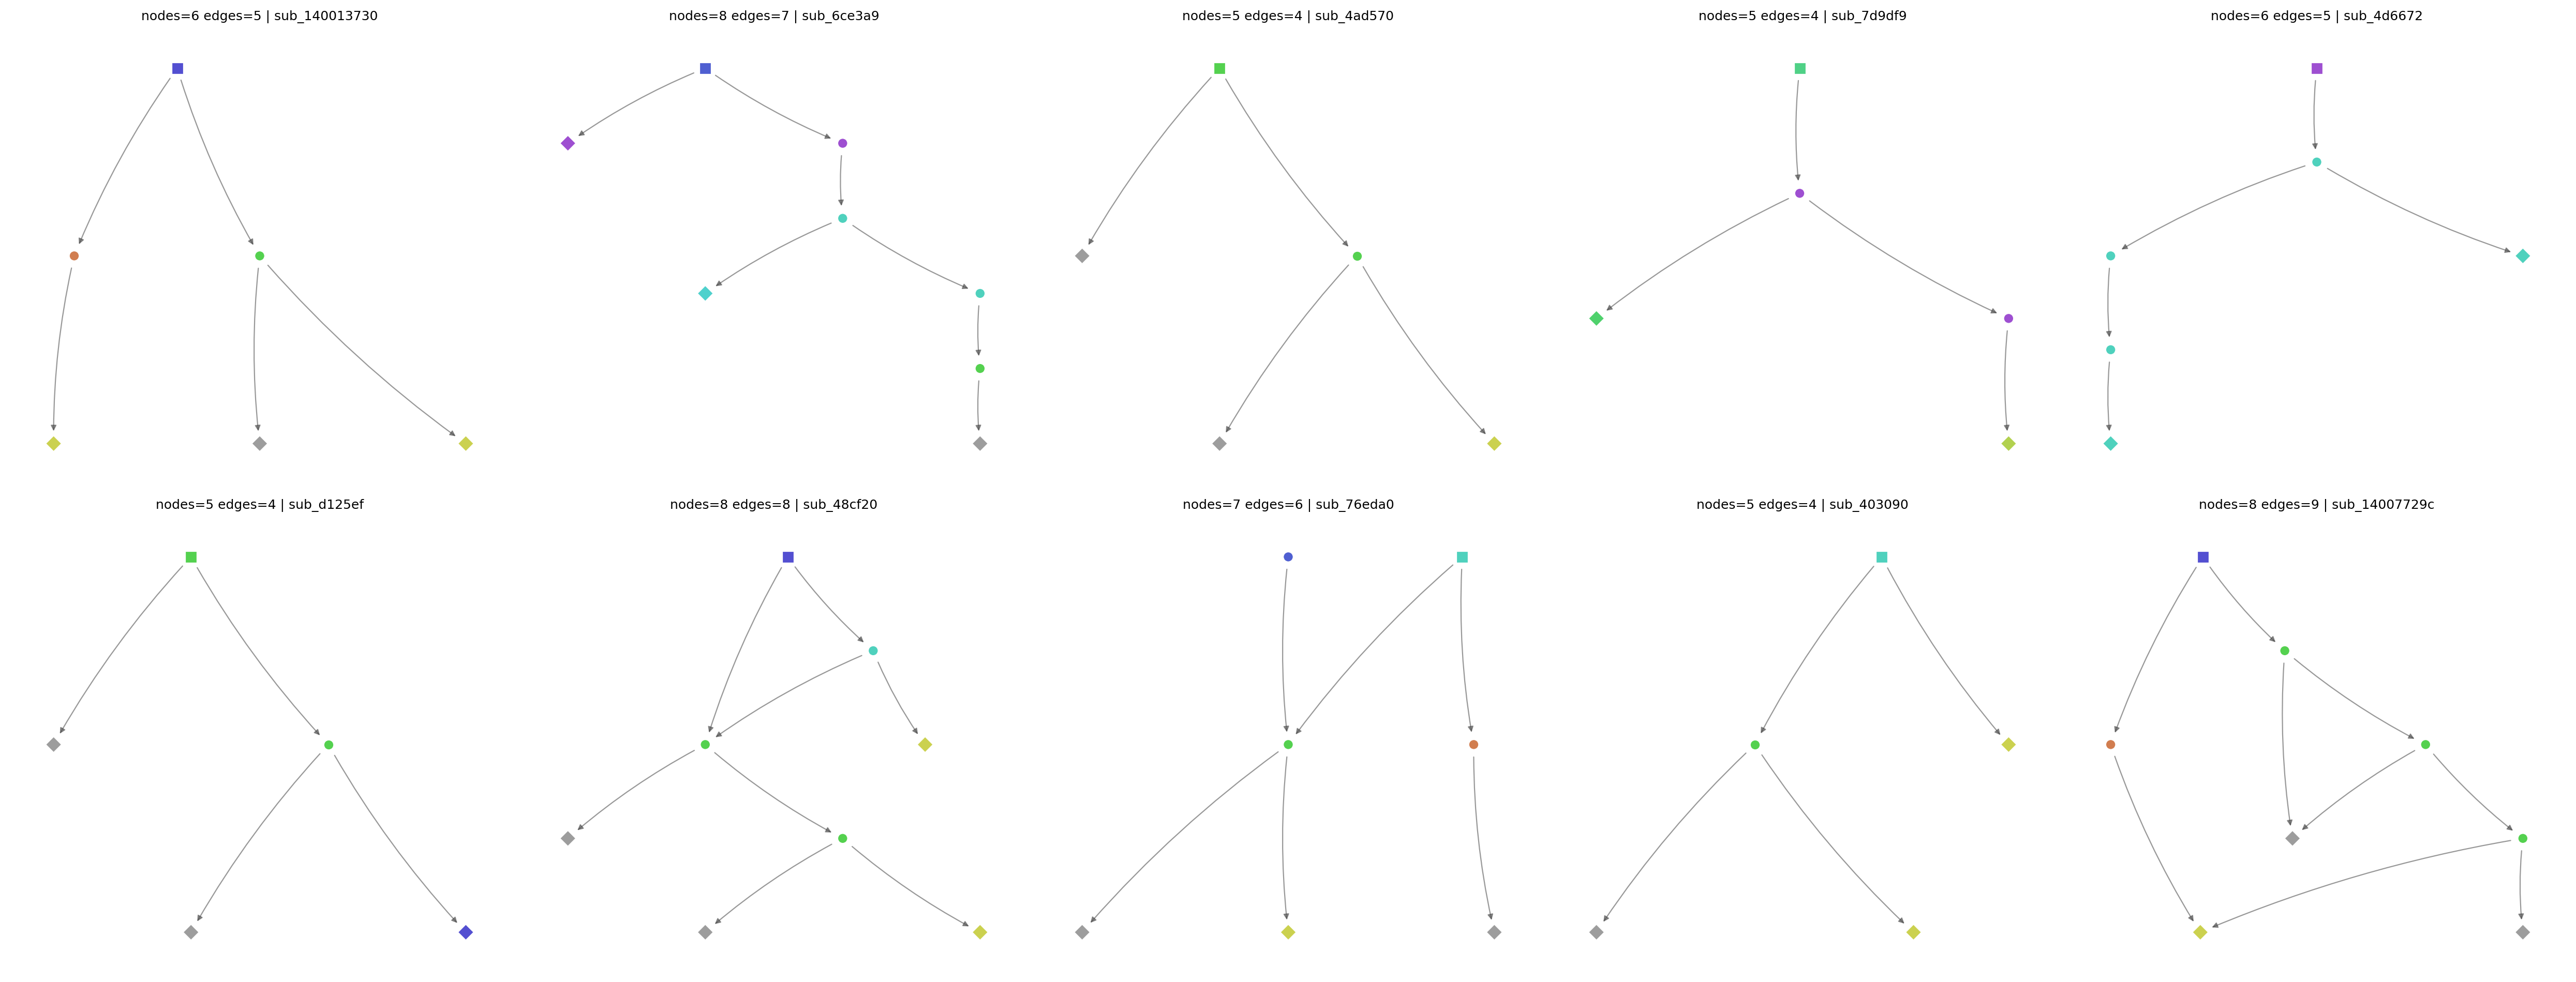

In [14]:
DATASET_PATH = Path(
    "/Users/fabriziocosta/Resilio Sync/Sync/Projects/ACTIVE/ControlFlowGraphsForMalware/processed_ml/balanced_mnemonic_networkx_graphs.pkl"
)

dataset_name = DATASET_PATH.stem
size = 300
min_num_nodes = 5
max_num_nodes = 10
USE_TARGETS = False
TARGET_MODE = "classification"

with DATASET_PATH.open("rb") as handle:
    all_graphs = pickle.load(handle)

candidate_graphs = [
    graph.copy()
    for graph in all_graphs
    if graph.is_directed()
    and min_num_nodes <= graph.number_of_nodes() <= max_num_nodes
    and graph.number_of_edges() > 0
]
random.Random(0).shuffle(candidate_graphs)
graphs = candidate_graphs[:size]
metadata = [dict(graph.graph) for graph in graphs]

def graph_target(graph):
    return graph.graph.get("binary_label", graph.graph.get("label"))

targets = [graph_target(graph) for graph in graphs] if USE_TARGETS else None

print(f"dataset: {dataset_name}")
print(f"source_path: {DATASET_PATH}")
print(f"raw_graphs: {len(all_graphs)}")
print(f"filtered_graphs: {len(candidate_graphs)}")
print(f"n_graphs: {len(graphs)}")
print(f"node_range: [{min_num_nodes}, {max_num_nodes}]")
print(f"all_directed: {all(graph.is_directed() for graph in graphs)}")
print(f"nodes: min={min(g.number_of_nodes() for g in graphs)} median={np.median([g.number_of_nodes() for g in graphs]):.0f} max={max(g.number_of_nodes() for g in graphs)}")
print(f"edges: min={min(g.number_of_edges() for g in graphs)} median={np.median([g.number_of_edges() for g in graphs]):.0f} max={max(g.number_of_edges() for g in graphs)}")
if USE_TARGETS:
    print(f"target_mode: {TARGET_MODE}")
    print(f"targets: {sorted(set(targets))}")
else:
    print("targets disabled")

_ = display_graphs(graphs[:10], n_graphs_per_line=5)


In [15]:
estimator_decomposition_function = add(neighborhood(radius=(1, 2)), path(number_of_edges=3))


def make_graph_transformer():
    return AbstractGraphTransformer(
        nbits=14,
        decomposition_function=estimator_decomposition_function,
        return_dense=True,
        n_jobs=-1,
    )


vectorizer = make_graph_transformer()

feasibility_kwargs = dict(
    nbits=19,
    parallel=True,
    backend="loky",
    n_jobs=-1,
)
partial_feasibility_estimators = [
    FeasibilityEstimatorFeatureCannotExist(
        decomposition_function=compose(neighborhood(radius=2), unlabel()),
        **feasibility_kwargs,
    ),
    FeasibilityEstimatorFeatureCannotExist(
        decomposition_function=neighborhood(radius=1),
        **feasibility_kwargs,
    ),
]
partial_feasibility_estimator = FeasibilityEstimator(partial_feasibility_estimators)

final_feasibility_estimators = [
    FeasibilityEstimatorFeatureCannotExist(
        decomposition_function=compose(neighborhood(radius=2), unlabel()),
        **feasibility_kwargs,
    ),
    FeasibilityEstimatorFeatureCannotExist(
        decomposition_function=neighborhood(radius=1),
        **feasibility_kwargs,
    ),
]
final_feasibility_estimator = FeasibilityEstimator(final_feasibility_estimators)

graph_estimator = GraphEstimator(
    transformer=vectorizer,
    estimator=RandomForestClassifier(
        random_state=0,
        n_estimators=300,
        n_jobs=-1,
        class_weight="balanced_subsample",
    ),
)

target_estimator = None
if USE_TARGETS:
    if TARGET_MODE == "classification":
        target_estimator = GraphEstimator(
            transformer=make_graph_transformer(),
            estimator=RandomForestClassifier(
                random_state=0,
                n_estimators=300,
                n_jobs=-1,
                class_weight="balanced_subsample",
            ),
        )
    else:
        target_estimator = GraphEstimator(
            transformer=make_graph_transformer(),
            estimator=RandomForestRegressor(
                random_state=0,
                n_estimators=300,
                n_jobs=-1,
            ),
        )

generator = EdgeGenerator(
    partial_feasibility_estimator=partial_feasibility_estimator,
    final_feasibility_estimator=final_feasibility_estimator,
    graph_estimator=graph_estimator,
    target_estimator=target_estimator,
    target_estimator_mode=TARGET_MODE,
    decomposition_function=add(cycle(), tree()),
    enforce_diversity=False,
    n_negative_per_positive=5,
    n_replicates=5,
    beam_size=2,
    max_restarts=2,
    fit_n_jobs=-1,
    fit_backend="loky",
    verbose=True,
    seed=0,
    require_single_connected_component=True,
)


In [16]:
%%time
generator.store(graphs, targets=targets)
print(f"stored_graphs = {len(generator.stored_graphs_)}")


stored_graphs = 300
CPU times: user 2.22 s, sys: 621 ms, total: 2.84 s
Wall time: 11.2 s


## Directed CFG Repair Workflow

Select one stored control-flow `DiGraph` at random, perturb it by moving `k` directed edges,
then repair it with `EdgeGenerator.repair(...)` using the nearest stored directed CFGs as the local fitting set.


graph_idx = 126
repair_target = None
k_directed_edge_moves = 2
original_edges = 6
perturbed_edges = 6
original_directed = True
perturbed_directed = True


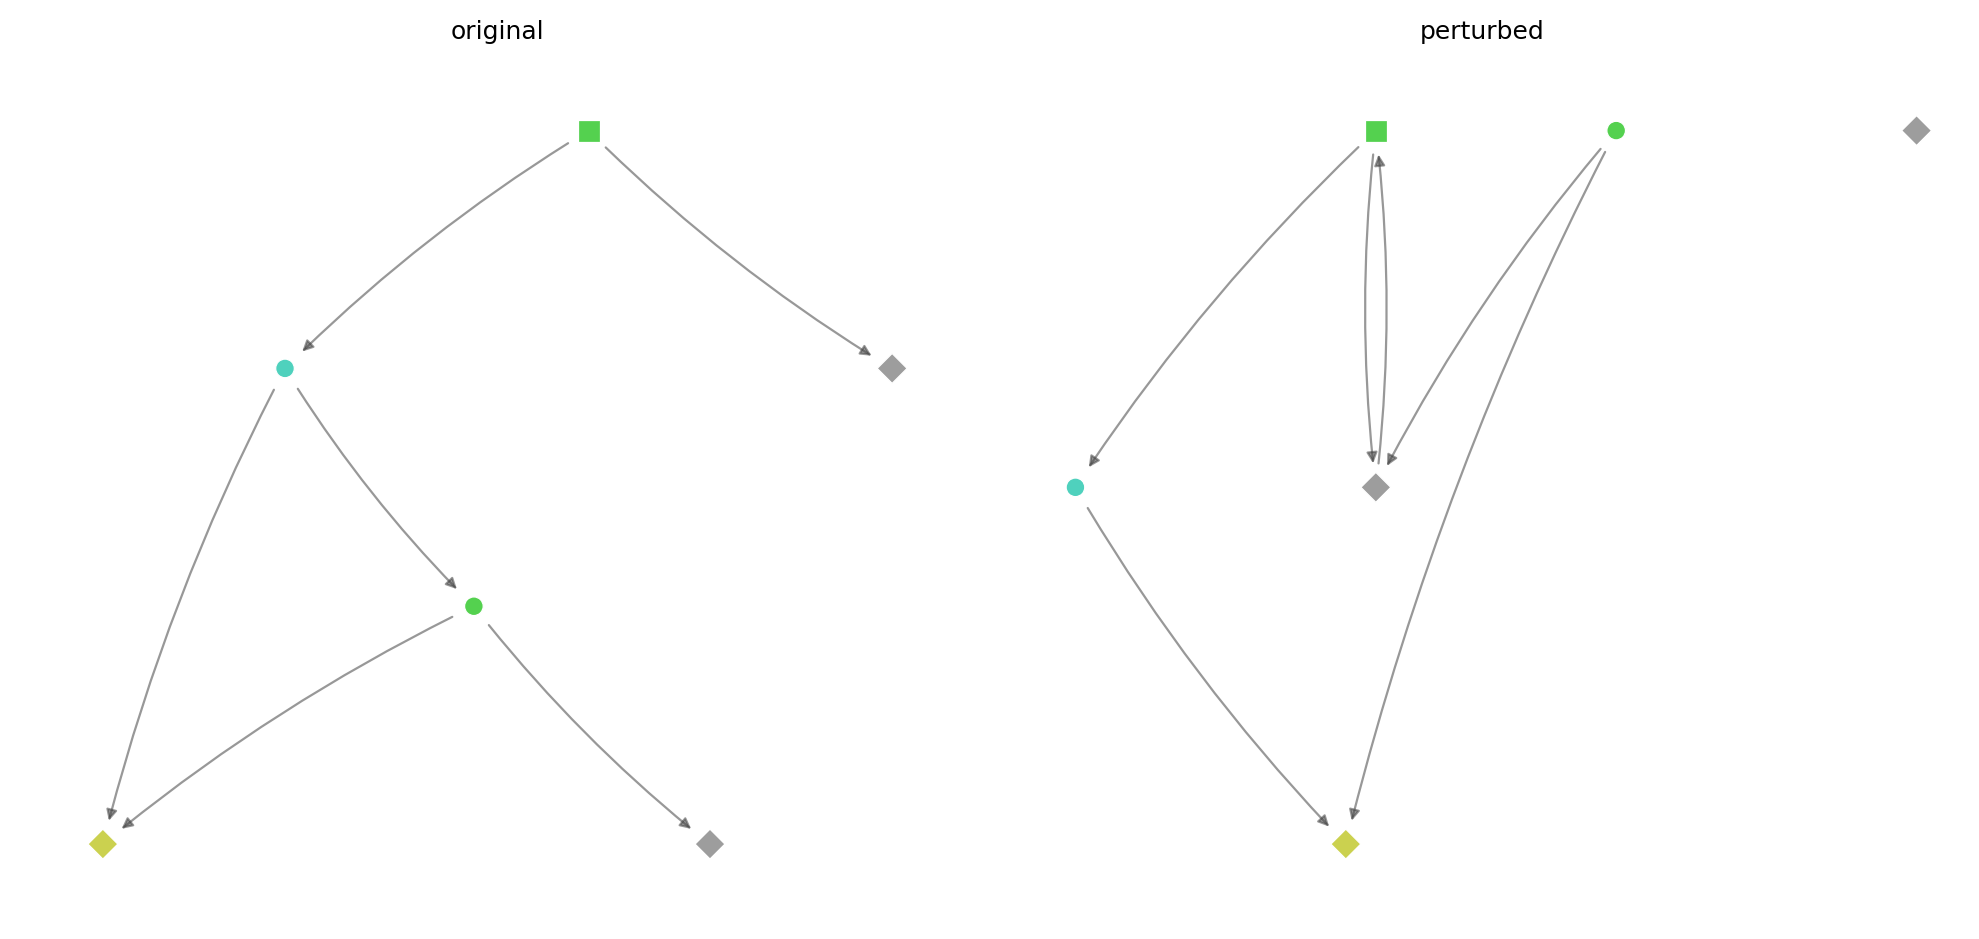

In [17]:
idx = random.randrange(len(graphs))
graph = graphs[idx]
repair_target = targets[idx] if USE_TARGETS else None

k = 2
perturb_seed = 0


def move_random_edges(graph, k, *, seed=0):
    perturbed = graph.copy()
    rng = random.Random(seed)
    for _ in range(max(0, int(k))):
        neighbors = edge_neighbors(
            perturbed,
            n_samples=1,
            seed=rng.randrange(10**9),
        )
        if not neighbors:
            break
        perturbed = neighbors[0]
    return perturbed


perturbed_graph = move_random_edges(graph, k, seed=perturb_seed)

print(f"graph_idx = {idx}")
print(f"repair_target = {repair_target}")
print(f"k_directed_edge_moves = {k}")
print(f"original_edges = {graph.number_of_edges()}")
print(f"perturbed_edges = {perturbed_graph.number_of_edges()}")
print(f"original_directed = {graph.is_directed()}")
print(f"perturbed_directed = {perturbed_graph.is_directed()}")
_ = display_graphs([graph, perturbed_graph], n_graphs_per_line=2, titles=["original", "perturbed"])


[repair] query_index=None n_neighbors=20 neighbor_indices=[218, 245, 291, 2, 8, 17, 55, 57, 69, 83, 118, 131, 136, 151, 155, 160, 169, 174, 200, 203] neighbor_distances=[12.49, 12.49, 12.49, 12.8452, 12.8452, 12.8452, 12.8452, 12.8452, 12.8452, 12.8452, 12.8452, 12.8452, 12.8452, 12.8452, 12.8452, 12.8452, 12.8452, 12.8452, 12.8452, 12.8452]


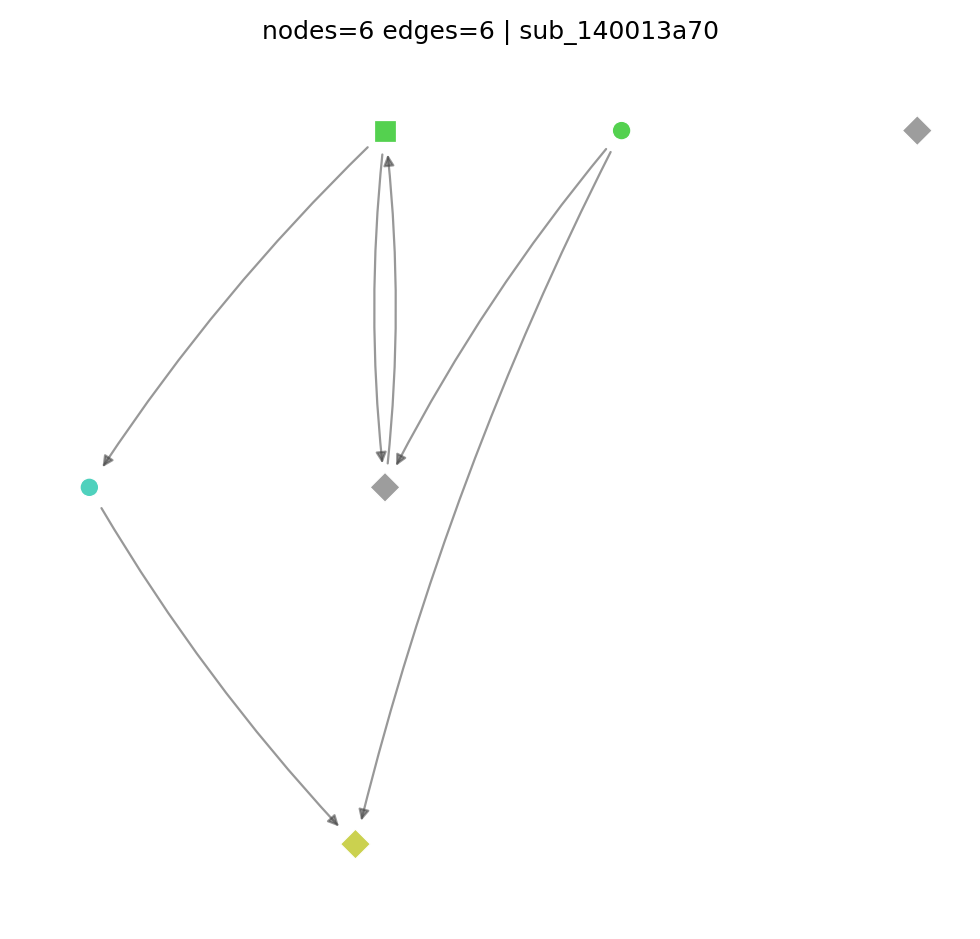

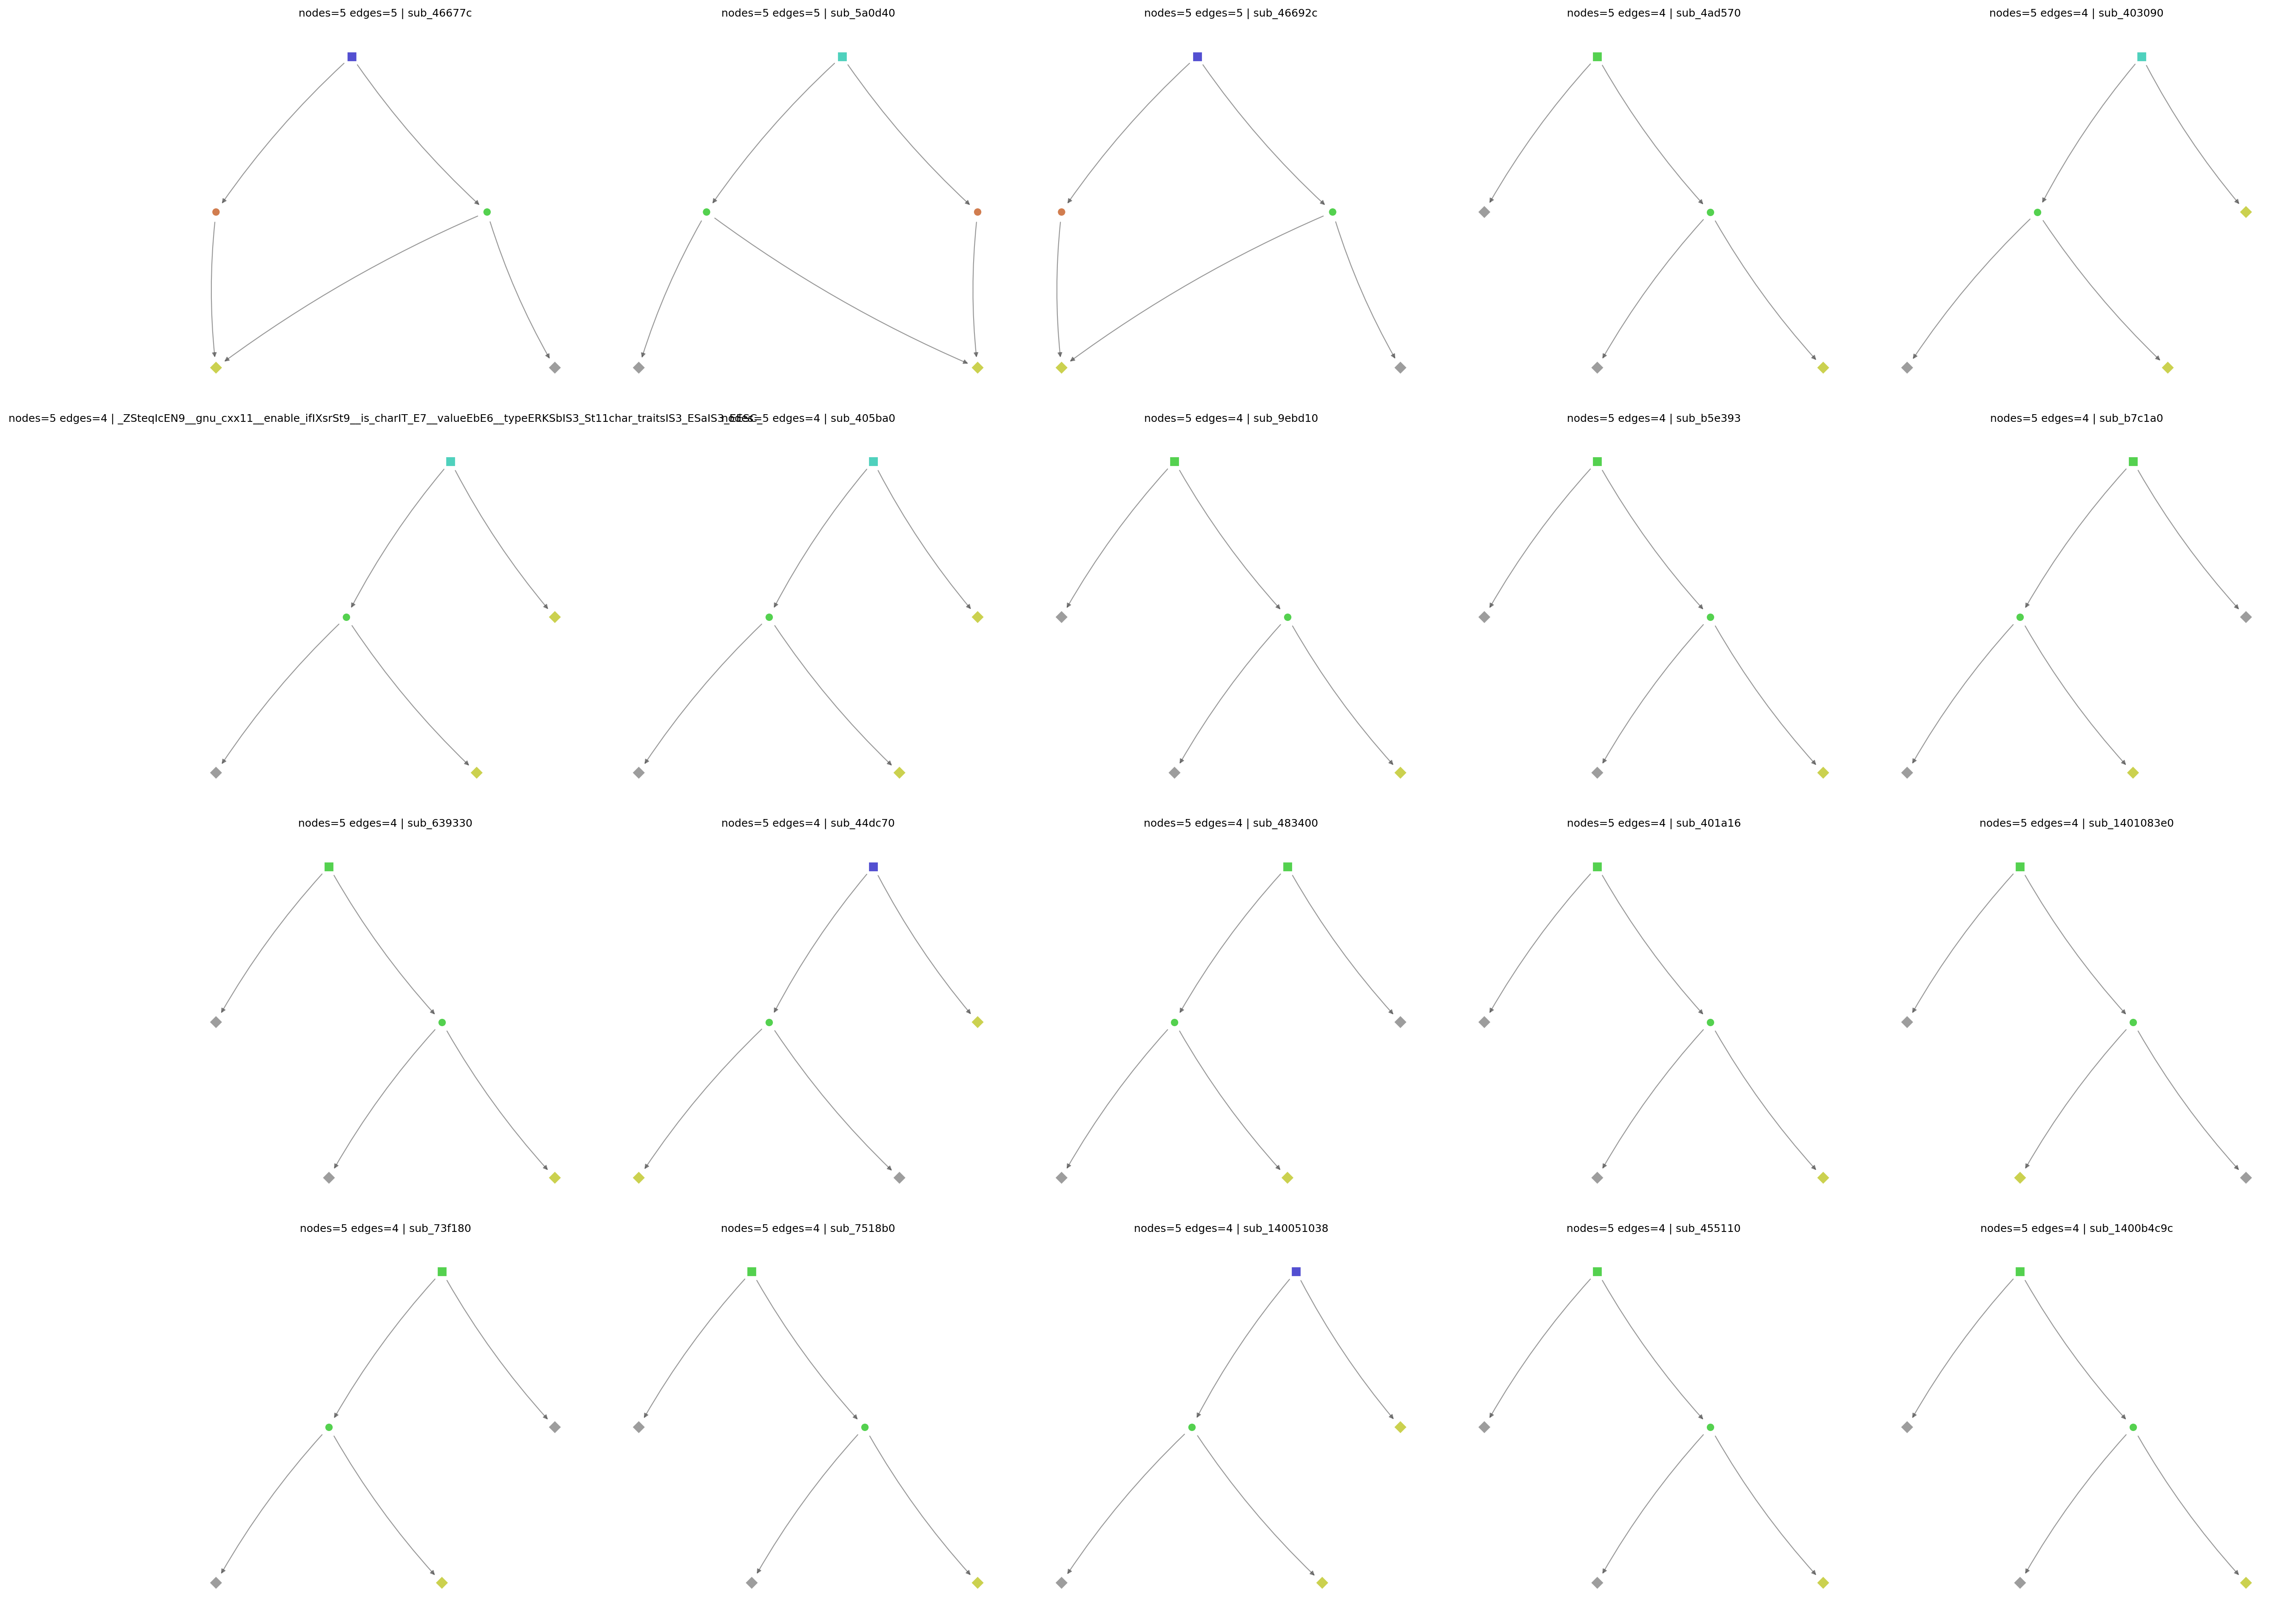

/Users/fabriziocosta/miniconda3/envs/py311/lib/python3.11/site-packages/networkx/utils/backends.py:535: UserWarning: The hashes produced for directed graphs changed in version v3.5 due to a bugfix to track in and out edges separately (see documentation).
  return self.orig_func(*args, **kwargs)


[fit] partial_feasibility_graphs=234 final_feasibility_graphs=20 positives=415 negatives=1575 dataset=1990 partial_time=0m 0.0s final_time=0m 0.0s
[fit] graph_estimator_graphs=1990 positive_labels=415 negative_labels=1575 time=0m 14.1s
[repair] attempt=1/1 start_edges=0 target_edges=6 removed_edges=[(5, 0), (0, 5), (1, 3), (0, 1), (4, 5), (4, 3)]


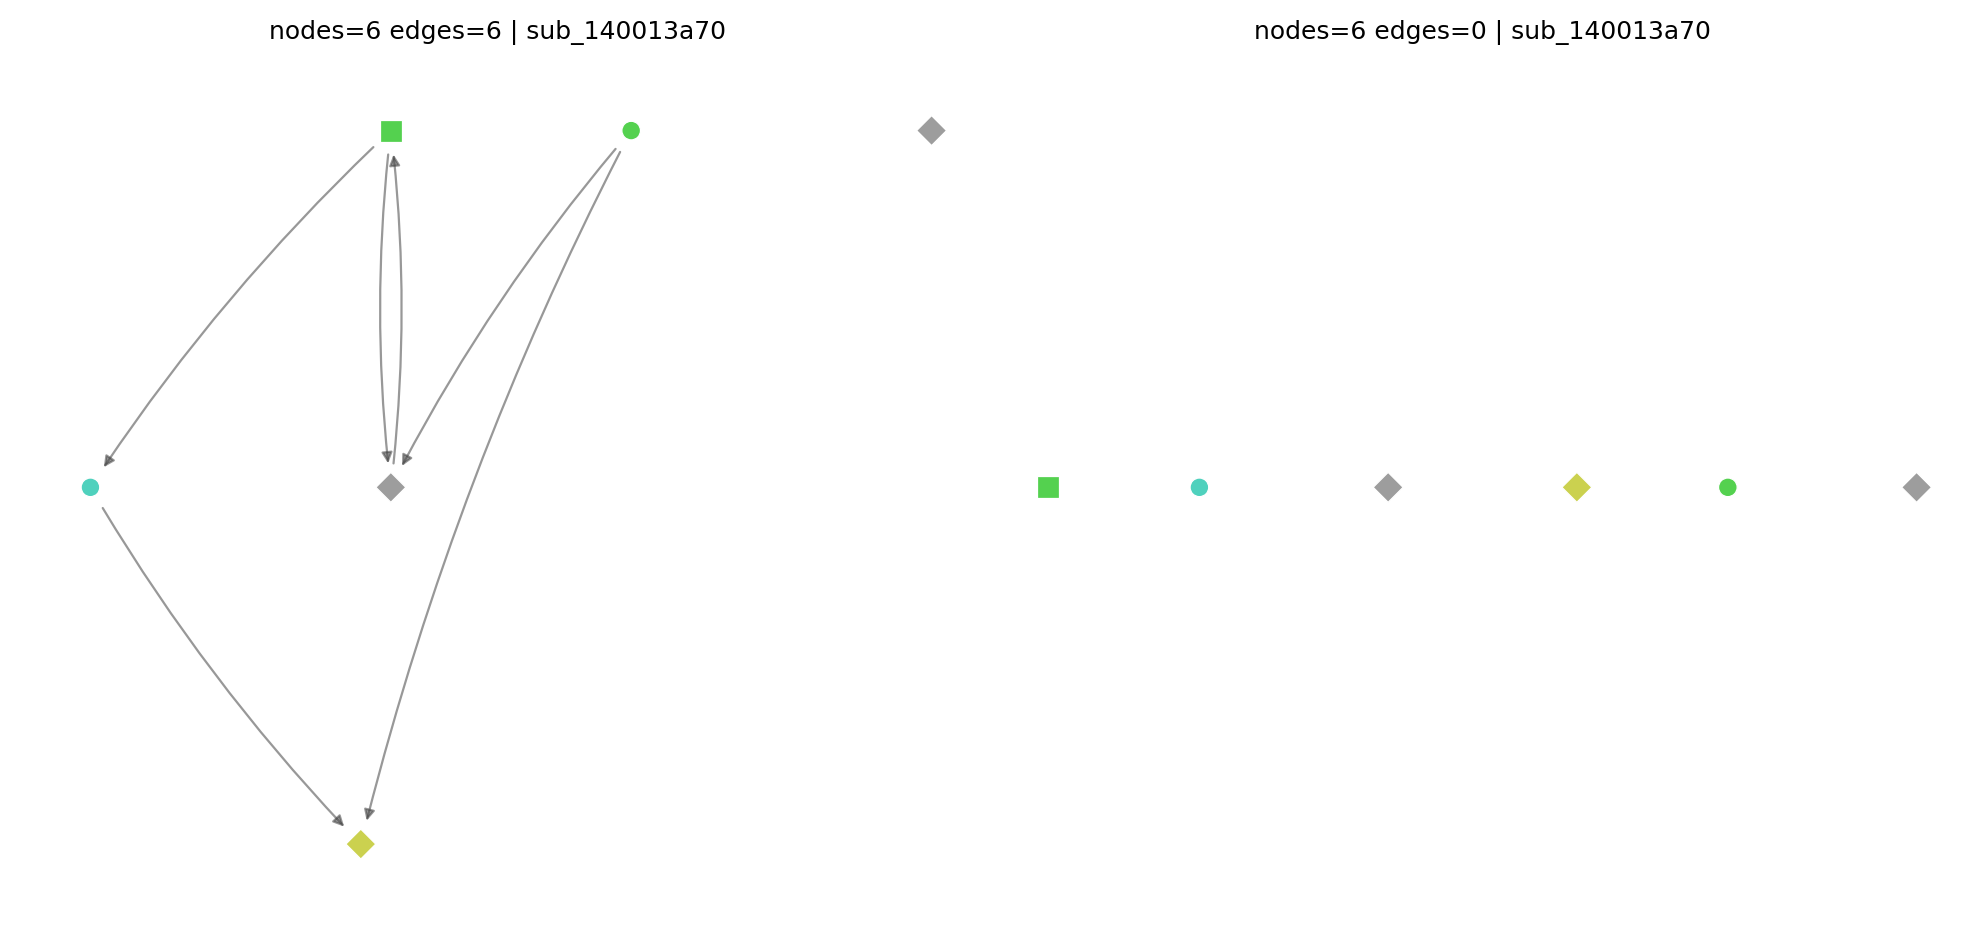

[graph 0] start start_edges=0 target_edges=6 remaining_edges=6


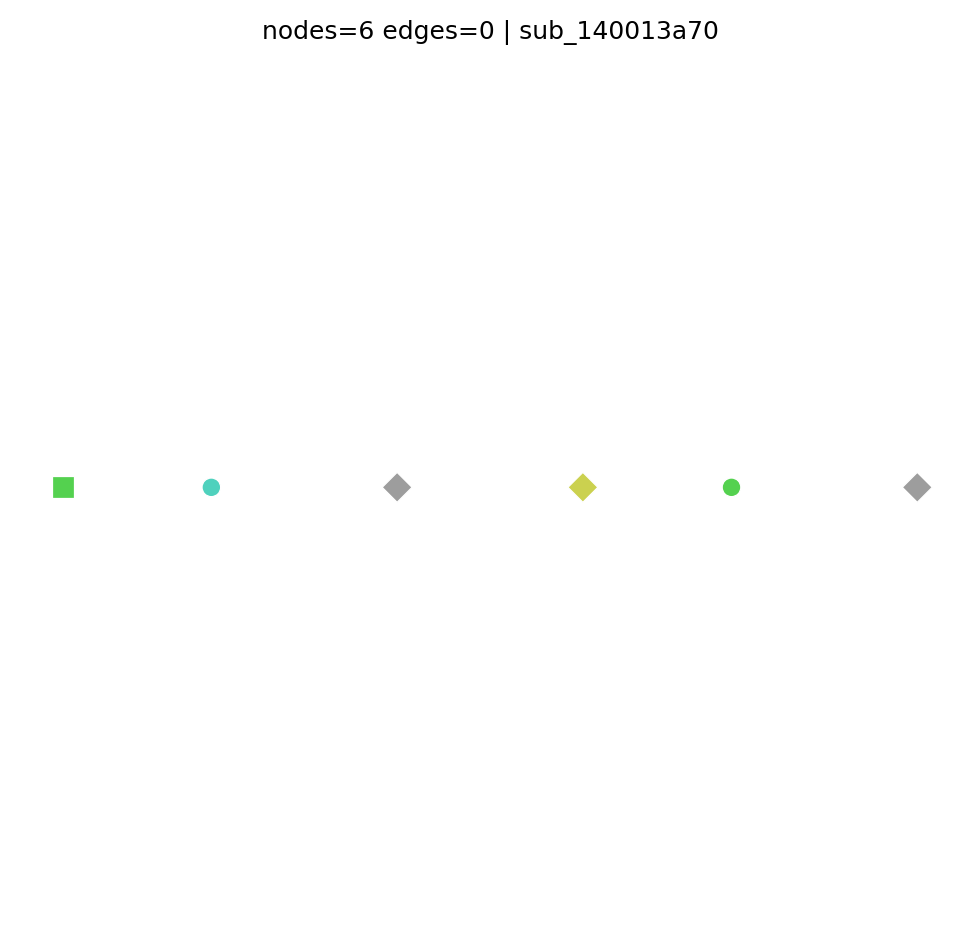

[graph 0] fallback=1/3 beam_limit=2
[graph 0] fallback=1/3 depth=1 remaining_edges=5 step_time=0m 15.1s eta=1m 15.5s
generated=1560 feasible=0 retained=0 tried=1560
best_score=None
beam_limit=2
[graph 0] BACKTRACK no feasible candidates remain; 2 fallback phase(s) left
[graph 0] fallback=1/2 rollback_steps=2 to_depth=0 beam_limit=3
[graph 0] fallback=2/3 beam_limit=3
[graph 0] fallback=2/3 depth=1 remaining_edges=5 step_time=0m 16.0s eta=1m 20.0s
generated=1560 feasible=0 retained=0 tried=3120
best_score=None
beam_limit=3
[graph 0] BACKTRACK no feasible candidates remain; 1 fallback phase(s) left
[graph 0] fallback=2/2 rollback_steps=4 to_depth=0 beam_limit=5
[graph 0] fallback=3/3 beam_limit=5
[graph 0] fallback=3/3 depth=1 remaining_edges=5 step_time=0m 17.8s eta=1m 29.2s
generated=1560 feasible=0 retained=0 tried=4680
best_score=None
beam_limit=5
[graph 0] FAILED no feasible candidates remain; no fallback phases left
[graph 0] failed target_edges=6 reason=Could not generate a feasib

In [18]:
%%time
n_neighbors = 20
repair_path = generator.repair(
    perturbed_graph,
    n_neighbors=n_neighbors,
    target=repair_target,
    target_lambda=0.5,
    return_path=True,
    draw_graphs_fn=lambda graphs, **kwargs: display_graphs(graphs, n_graphs_per_line=5, **kwargs),
)

print(f"repair_path_length = {len(repair_path)}")
if len(repair_path) > 0:
    print(f"final_n_edges = {repair_path[-1].number_of_edges()}")
    display_graphs(repair_path, n_graphs_per_line=5)
    print("Original and perturbed graphs:")
    display_graphs([graph, perturbed_graph], n_graphs_per_line=2, titles=["original", "perturbed"])
    print("Repaired graph:")
    display_graphs([repair_path[-1]], n_graphs_per_line=1, titles=["repaired"])
    print("Repair training set:")
    display_graphs(generator.last_repair_training_graphs_, n_graphs_per_line=5)


---
